In [2]:
import numpy as np
from scipy.stats.qmc import Sobol
from scipy.spatial import cKDTree

In [ ]:
def generate_sobol_with_exclusion(dimensions: int,
                                  num_points: int,
                                  bounds: list[tuple[float, float]],
                                  existing: np.ndarray | None = None,
                                  min_dist: float = 1e-6,
                                  oversample_factor: int = 4,
                                  scramble: bool = True) -> np.ndarray:
    """
    Generate 'num_points' Sobol samples inside 'bounds'
    """
    # Prepare KD-tree for fast radius queries
    tree_exist = cKDTree(existing) if (existing is not None and existing.size) else None
    accepted = []

    # Sobol engine
    sob = Sobol(d=dimensions, scramble=scramble)
    m = int(np.ceil(np.log2(num_points * oversample_factor)))  # start size

    while len(accepted) < num_points:
        cand = sob.random_base2(m=m)

        # Scale to the provided bounds
        for j, (lo, hi) in enumerate(bounds):
            cand[:, j] = cand[:, j] * (hi - lo) + lo


        if tree_exist is not None:
            good = tree_exist.query(cand, k=1)[0] >= min_dist
            cand = cand[good]

        if accepted:
            tree_new = cKDTree(np.asarray(accepted))
            good = tree_new.query(cand, k=1)[0] >= min_dist
            cand = cand[good]

        accepted.extend(cand.tolist())
        m += 1

    return np.asarray(accepted[:num_points])




In [24]:

dims = 3
N_new = 100
bnds = [(0, 1), (0, 1), (0, 1)]

# Existing random samples (shape = [K, dims], already scaled)
np.random.seed(42)
existing_samples = np.column_stack([np.random.uniform(low, high, 20) for low, high in bnds])

samples = generate_sobol_with_exclusion(dims, N_new, bnds, existing_samples,
                                        min_dist=0.1)

print("Generated:", samples.shape)


Generated: (100, 3)


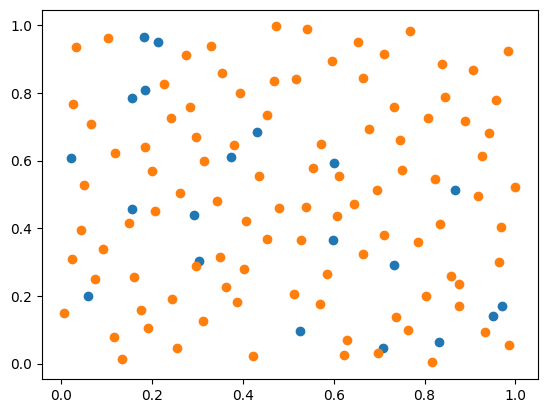

In [25]:
import matplotlib.pyplot as plt
plt.figure()
plt.scatter(existing_samples[:, 0], existing_samples[:, 1])
plt.scatter(samples[:, 0], samples[:, 1])
plt.show()